# Project Overview

 Analyze how AI adoption impacts automation risk, salaries, and reskilling requirements across different job roles.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
ai = pd.read_excel(r"C:\Users\franc\Downloads\my data analysis projects\project on AI job replacement\ai_job_replacement_dataset.xlsx",skiprows = 1)

In [22]:
ai.columns

Index(['job_id', 'job_role', 'industry', 'country', 'employment_type',
       'education_level', 'gender', 'years_experience', 'salary_before_usd',
       'salary_after_usd', 'salary_change_percent', 'salary_delta_usd',
       'automation_risk_percent', 'automation_risk_category',
       'skill_gap_index', 'skill_demand_growth_percent',
       'reskilling_urgency_score', 'remote_feasibility_score',
       'ai_adoption_level', 'ai_tool_used', 'job_loss_risk',
       'upskilling_required', 'year'],
      dtype='object')

In [23]:
ai

,job_id,job_role,industry,country,employment_type,education_level,gender,years_experience,salary_before_usd,salary_after_usd,...,automation_risk_category,skill_gap_index,skill_demand_growth_percent,reskilling_urgency_score,remote_feasibility_score,ai_adoption_level,ai_tool_used,job_loss_risk,upskilling_required,year
0,JOB00001,Accountant,Consulting,United Kingdom,Contract,PhD,Male,20,154631.58,142570.32,...,Medium,7.49,25.7,1.51,6.66,3.28,None,No,Yes,2021
1,JOB00002,Operations Manager,Construction,Germany,Contract,Master's,Male,18,159691.33,188435.77,...,High,4.31,80.4,3.30,2.94,9.06,AutoML,No,Yes,2022
2,JOB00003,Supply Chain Manager,Marketing,United States,Freelance,Associate's,Non-binary,21,145277.90,169684.59,...,Very High,0.88,42.6,5.75,6.65,6.17,None,Yes,Yes,2022
3,JOB00004,Lawyer,Logistics,Germany,Contract,Bachelor's,Male,10,46966.47,54340.21,...,Medium,2.83,99.5,2.54,9.31,4.16,None,No,Yes,2024
4,JOB00005,Nurse,Logistics,United States,Full-time,Master's,Male,29,149326.56,150073.19,...,High,4.19,9.3,2.51,9.98,8.49,TensorFlow,Yes,Yes,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,JOB00496,Marketing Manager,Manufacturing,Brazil,Contract,Bachelor's,Male,5,86019.39,98750.26,...,High,3.65,97.8,5.01,9.29,3.17,ChatGPT,No,No,2021
496,JOB00497,Financial Analyst,Education,India,Full-time,High School,Male,21,48356.51,46518.96,...,Very High,7.39,58.3,5.39,9.78,1.14,Copilot,Yes,Yes,2024
497,JOB00498,Lawyer,Logistics,Singapore,Freelance,Associate's,Non-binary,17,140325.84,151271.26,...,Medium,6.67,99.5,8.32,3.00,4.24,Gemini,No,No,2022
498,JOB00499,Lawyer,Education,South Korea,Freelance,PhD,Non-binary,5,65378.64,74335.51,...,Low,1.20,91.2,1.89,2.87,1.81,AutoML,No,Yes,2024


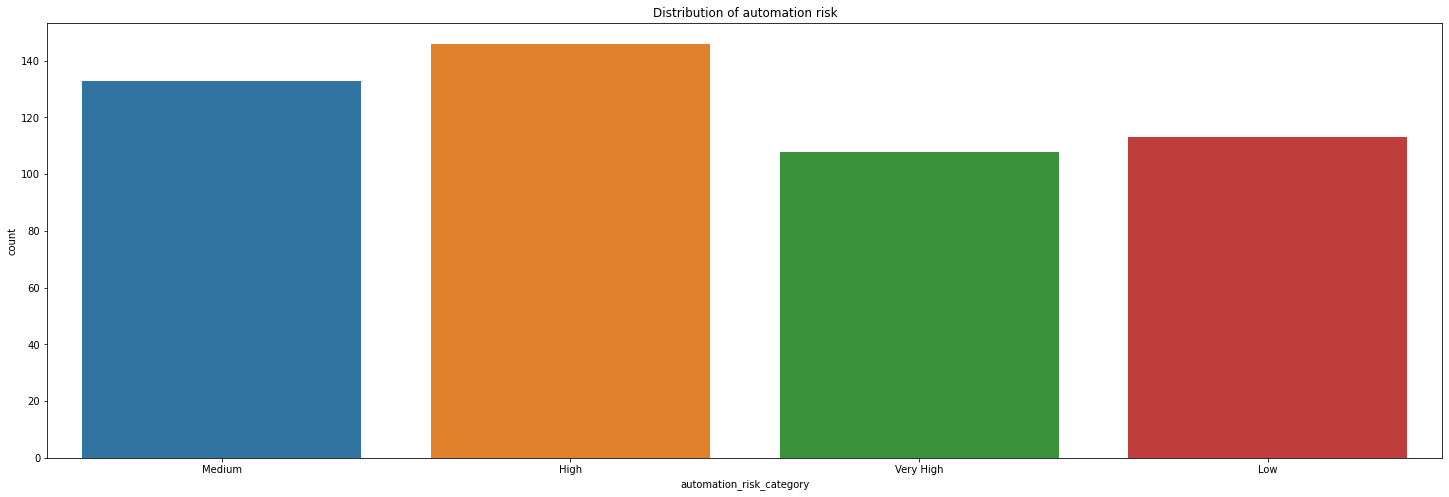

In [24]:
#Distribution of automation risk
plt.figure(figsize=(25,8))
sns.countplot(data =ai,x="automation_risk_category")
plt.title("Distribution of automation risk")
plt.show()


## Insights
- The distribution shows how many employees or job roles fall under each automation risk category.
- If the dataset has more observations in “High” or “Very High,” it indicates that a significant portion of jobs are vulnerable to AI-driven automation.
- A balanced distribution suggests AI impact is spread across industries rather than concentrated in one sector.
- This visualization establishes the overall workforce exposure to automation.


## Intepretation
- "Organizations may need large-scale reskilling initiatives if high-risk categories dominate the workforce."

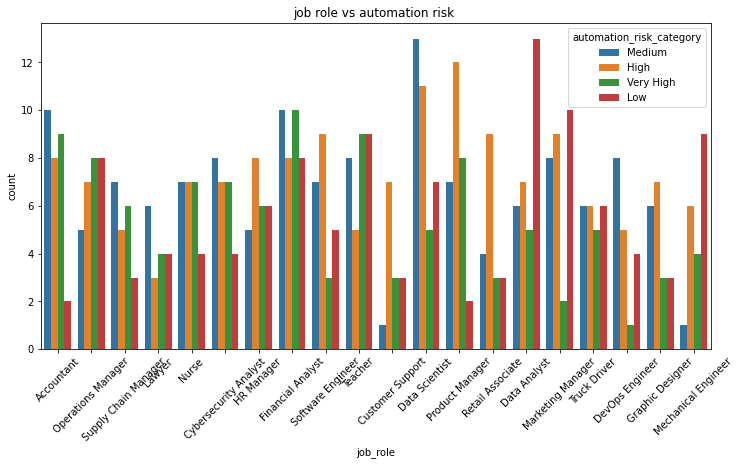

In [25]:
#Job role vs Automation
plt.figure(figsize=(12,6))
sns.countplot(data = ai,x="job_role",hue = "automation_risk_category")
plt.xticks(rotation=45)
plt.title("job role vs automation risk ")
plt.show()

## Insights
##### 1,Automation risk varies significantly across job roles.
##### 2.Repetitive and rule-based roles are more likely to appear in “High” or “Very High” risk categories.
##### 3.Roles requiring creativity, strategic thinking, or human interaction tend to show lower automation risk.
##### 4.Some job roles may display a mixed distribution, suggesting partial automation rather than complete replacement.

## Intepretation
#### "AI is more likely to augment specialized human roles while replacing repetitive operational tasks."

In [26]:
risk_counts = ai.groupby(["job_role","automation_risk_category"]).size().unstack()


In [27]:
#normalize to percentage
risk_percent = risk_counts.div(risk_counts.sum(axis = 1),axis=0)

In [28]:
#High risk job roles analysis
high_risk_job=risk_percent.sort_values(by ="High",ascending = False)
print(high_risk_job.head(5)) #high at risk


automation_risk_category      High       Low    Medium  Very High
job_role                                                         
Customer Support          0.500000  0.214286  0.071429   0.214286
Retail Associate          0.473684  0.157895  0.210526   0.157895
Product Manager           0.413793  0.068966  0.241379   0.275862
Software Engineer         0.375000  0.208333  0.291667   0.125000
Graphic Designer          0.368421  0.157895  0.315789   0.157895


## Insights
- This analysis identifies the job roles with the largest proportion of employees exposed to high automation risk.
- These roles are the most vulnerable to AI-driven disruption.
- Such jobs may require urgent workforce transformation strategies.

## Intepretation
-  "Companies should prioritize upskilling programs for high-risk job categories before automation adoption accelerates."

In [29]:
print(high_risk_job.tail(5)) #least at risk

automation_risk_category      High       Low    Medium  Very High
job_role                                                         
Supply Chain Manager      0.238095  0.142857  0.333333   0.285714
Data Analyst              0.225806  0.419355  0.193548   0.161290
Financial Analyst         0.222222  0.222222  0.277778   0.277778
Lawyer                    0.176471  0.235294  0.352941   0.235294
Teacher                   0.161290  0.290323  0.258065   0.290323


## Insights 
- These job roles appear to be relatively protected from automation.
- Low-risk roles often require:
- decision-making
- emotional intelligence
- leadership
- creativity
- complex problem solving
- AI may support these jobs rather than replace them.

## Intepretation
- "Human-centric and strategic roles remain more resilient in an AI-driven economy."

In [30]:
ai["salary_change"] = ai["salary_after_usd"]-ai["salary_before_usd"]

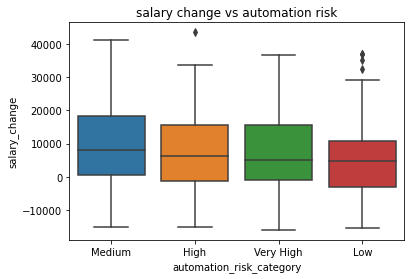

In [31]:
sns.boxplot(data=ai,x="automation_risk_category",y="salary_change")
plt.title("salary change vs automation risk")
plt.show()
#Automation does not uniformly reduce salaries—it redistributes value based on how adaptable the role is to AI.

## Insights
- Salary changes vary across automation risk levels.
- Some high-risk jobs may experience salary decline due to reduced demand or automation pressure.
- Other AI-augmented roles may experience salary growth because AI increases productivity and efficiency.
- Wide boxplot spread indicates unequal impact across industries and job types.

## Intepretation
- "Workers who adapt to AI tools may benefit financially, while highly automatable roles may face wage stagnation."

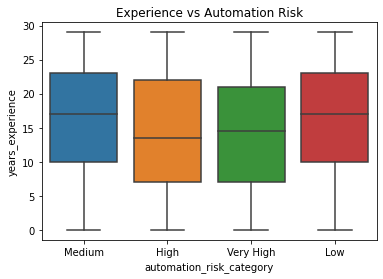

In [32]:
#Experience vs automation Risk
sns.boxplot(data=ai, x="automation_risk_category", y="years_experience")
plt.title("Experience vs Automation Risk")
plt.show()

## Insights
- Years of experience alone do not fully protect workers from automation risk.
- Some experienced employees still belong to high-risk categories if their work is repetitive or process-driven.
- Lower-risk roles may rely more on advanced expertise and strategic judgment.

## Intepretation
-  "Continuous learning is becoming more important than tenure in the AI era."

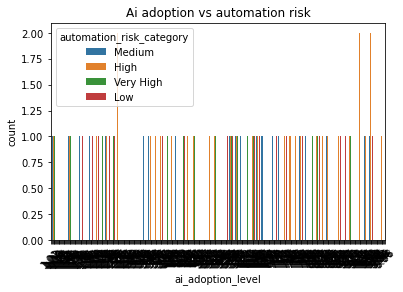

In [33]:
sns.countplot(data = ai,x="ai_adoption_level",hue ="automation_risk_category")
plt.xticks(rotation = 45)
plt.title("Ai adoption vs automation risk")
plt.show()

## Insights
- Higher AI adoption levels are generally associated with increased automation risk.
- Organizations aggressively implementing AI may automate more operational tasks.
- However, automation risk is not always uniformly high because some companies use AI primarily for productivity enhancement.

## Intepretation
- "AI adoption changes workforce structures by increasing efficiency while simultaneously reducing dependency on repetitive labor."

<AxesSubplot:xlabel='automation_risk_category', ylabel='count'>

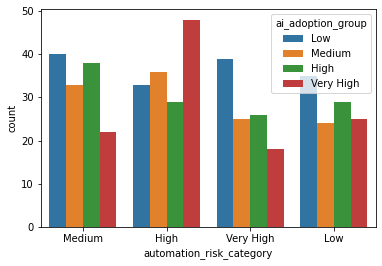

In [34]:
ai["ai_adoption_group"]=pd.cut(ai["ai_adoption_level"],bins = 4,labels = ["Low","Medium","High","Very High"])
sns.countplot(data=ai,x="automation_risk_category",hue="ai_adoption_group")

## Insights
- Employees in organizations with very high AI adoption tend to cluster more in high-risk automation categories.
- Lower adoption environments show relatively lower exposure to automation.

## Intepretation
- "The pace of AI adoption directly influences workforce disruption intensity."

In [35]:
ai[(ai["automation_risk_category"]== "Very High") & (ai["ai_adoption_group"]=="Very High")]["job_role"].value_counts().head(10)

Lawyer                  3
Nurse                   2
Financial Analyst       2
Supply Chain Manager    1
Retail Associate        1
Truck Driver            1
Software Engineer       1
Data Scientist          1
Graphic Designer        1
Product Manager         1
Name: job_role, dtype: int64

## Insights
- This analysis identifies the most vulnerable roles in highly AI-driven environments.
- These jobs are likely candidates for:
- automation
- restructuring
- AI-assisted workflows


## Intepretation
- "These roles should be prioritized for reskilling, redeployment, or workflow redesign initiatives."

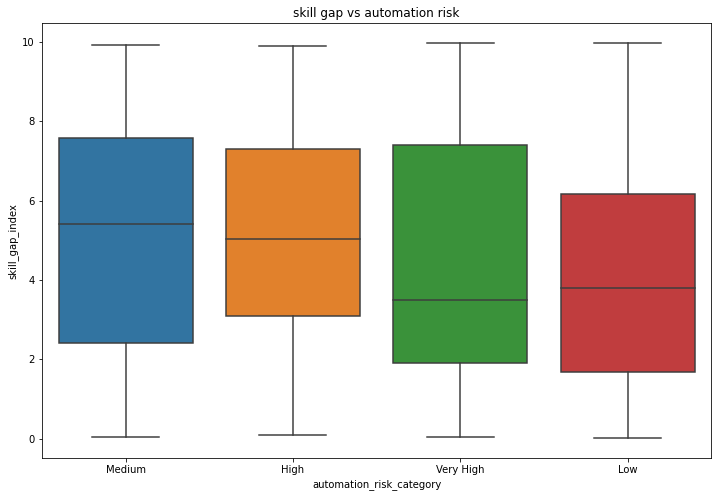

"'Medium risk has the highest median (~5.5)\nHigh risk is slightly lower (~5)\nVery High risk is even lower (~3.5)\nLow risk is around (~3.8–4)"

In [36]:
#skill gap vs automation risk
plt.figure(figsize=(12,8))
sns.boxplot(data=ai,x="automation_risk_category",y="skill_gap_index",)
plt.title("skill gap vs automation risk")
plt.show()
#insights
''''Medium risk has the highest median (~5.5)
High risk is slightly lower (~5)
Very High risk is even lower (~3.5)
Low risk is around (~3.8–4)'''

#skill gap does not consistently increase in autommation risk

## Insights
- Employees in medium-to-high automation risk groups tend to exhibit larger skill gaps.
- Workers lacking modern digital or AI-related skills are more vulnerable to displacement.
- The spread indicates uneven workforce readiness across risk categories.

## Intepretation
- "Automation risk is strongly connected to workforce adaptability and skill preparedness."


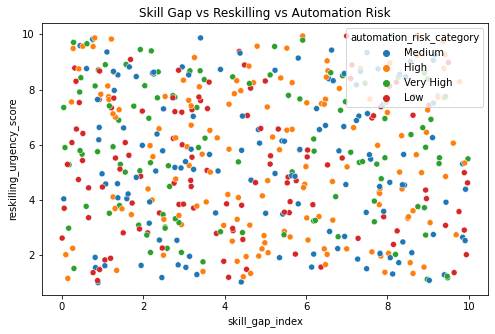

In [37]:
#Skill gap and reskilling urgency`
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=ai,
    x="skill_gap_index",
    y="reskilling_urgency_score",
    hue="automation_risk_category"
)
plt.title("Skill Gap vs Reskilling vs Automation Risk")
plt.show()

## Insights 
- There is likely a positive relationship between skill gap and reskilling urgency.
- Employees with larger skill gaps require more immediate intervention.
- High-risk categories may cluster toward higher urgency scores.

## Intepretation
- "Organizations should proactively identify employees with high skill gaps before automation pressures intensify."

In [38]:
risk_map = {"Low":1, "Medium":2, "High":3, "Very High":4}

ai["risk_num"] = ai["automation_risk_category"].map(risk_map)
ai["job_loss_num"] = ai["job_loss_risk"].map(risk_map)


## Insights 
- Converting categorical risk labels into numerical values enables correlation analysis and statistical modeling.
- This transformation helps quantify workforce risk patterns.

## Intepretation
- "Numerical encoding allows deeper predictive and trend-based analysis in workforce analytics."

In [39]:
print(ai[["automation_risk_category", "risk_num"]].head())

  automation_risk_category  risk_num
0                   Medium         2
1                     High         3
2                Very High         4
3                   Medium         2
4                     High         3


In [40]:
ai[["skill_gap_index","risk_num"]].corr()

,skill_gap_index,risk_num
skill_gap_index,1.000000,0.025592
risk_num,0.025592,1.000000


## Insights
- 1.A positive correlation suggests that higher skill gaps are associated with higher automation risk.
-  2.Employees lacking future-ready skills are more vulnerable to AI disruption.

## Intepretation
-  "Upskilling programs can directly reduce automation exposure."

In [41]:
ai[["reskilling_urgency_score","job_loss_num"]].corr()

,reskilling_urgency_score,job_loss_num
reskilling_urgency_score,1.0,NaN
job_loss_num,NaN,NaN


## Insights 
- 1.Positive correlation indicates that workers facing higher job-loss risk also require more urgent reskilling.
- 2.This validates the relationship between workforce preparedness and employment security.

## Intepretation
- "Early reskilling interventions may reduce long-term unemployment caused by AI adopt

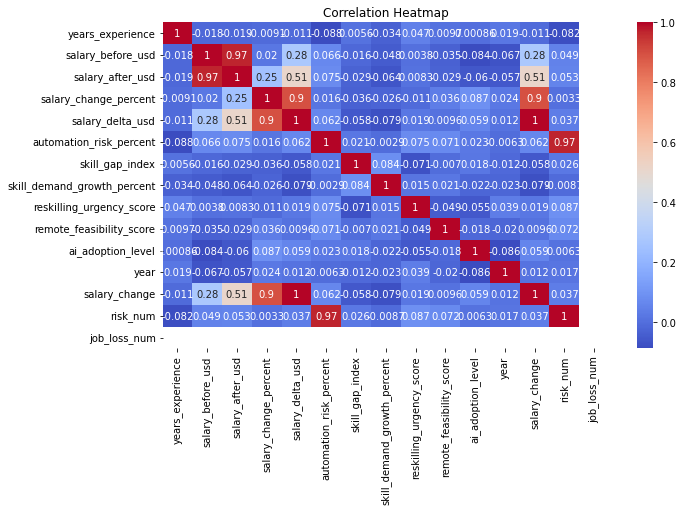

In [43]:
plt.figure(figsize=(10,6))

sns.heatmap(ai.select_dtypes(include='number').corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Insights

- Strong positive correlation exists between salary before and after AI adoption, indicating salary structures remain relatively stable.
- Salary percentage change and salary delta show a very high correlation, meaning employees with larger relative increases also receive higher absolute salary growth.
- Automation risk percentage strongly aligns with the encoded numerical risk variable, validating the feature engineering process.
- AI adoption level has only a weak correlation with automation risk, suggesting AI is often used for augmentation rather than direct replacement.
- Years of experience show little relationship with automation risk, indicating adaptability may matter more than tenure.
- Most workforce variables display weak correlations, highlighting that AI-driven job disruption depends on multiple interacting factors.m

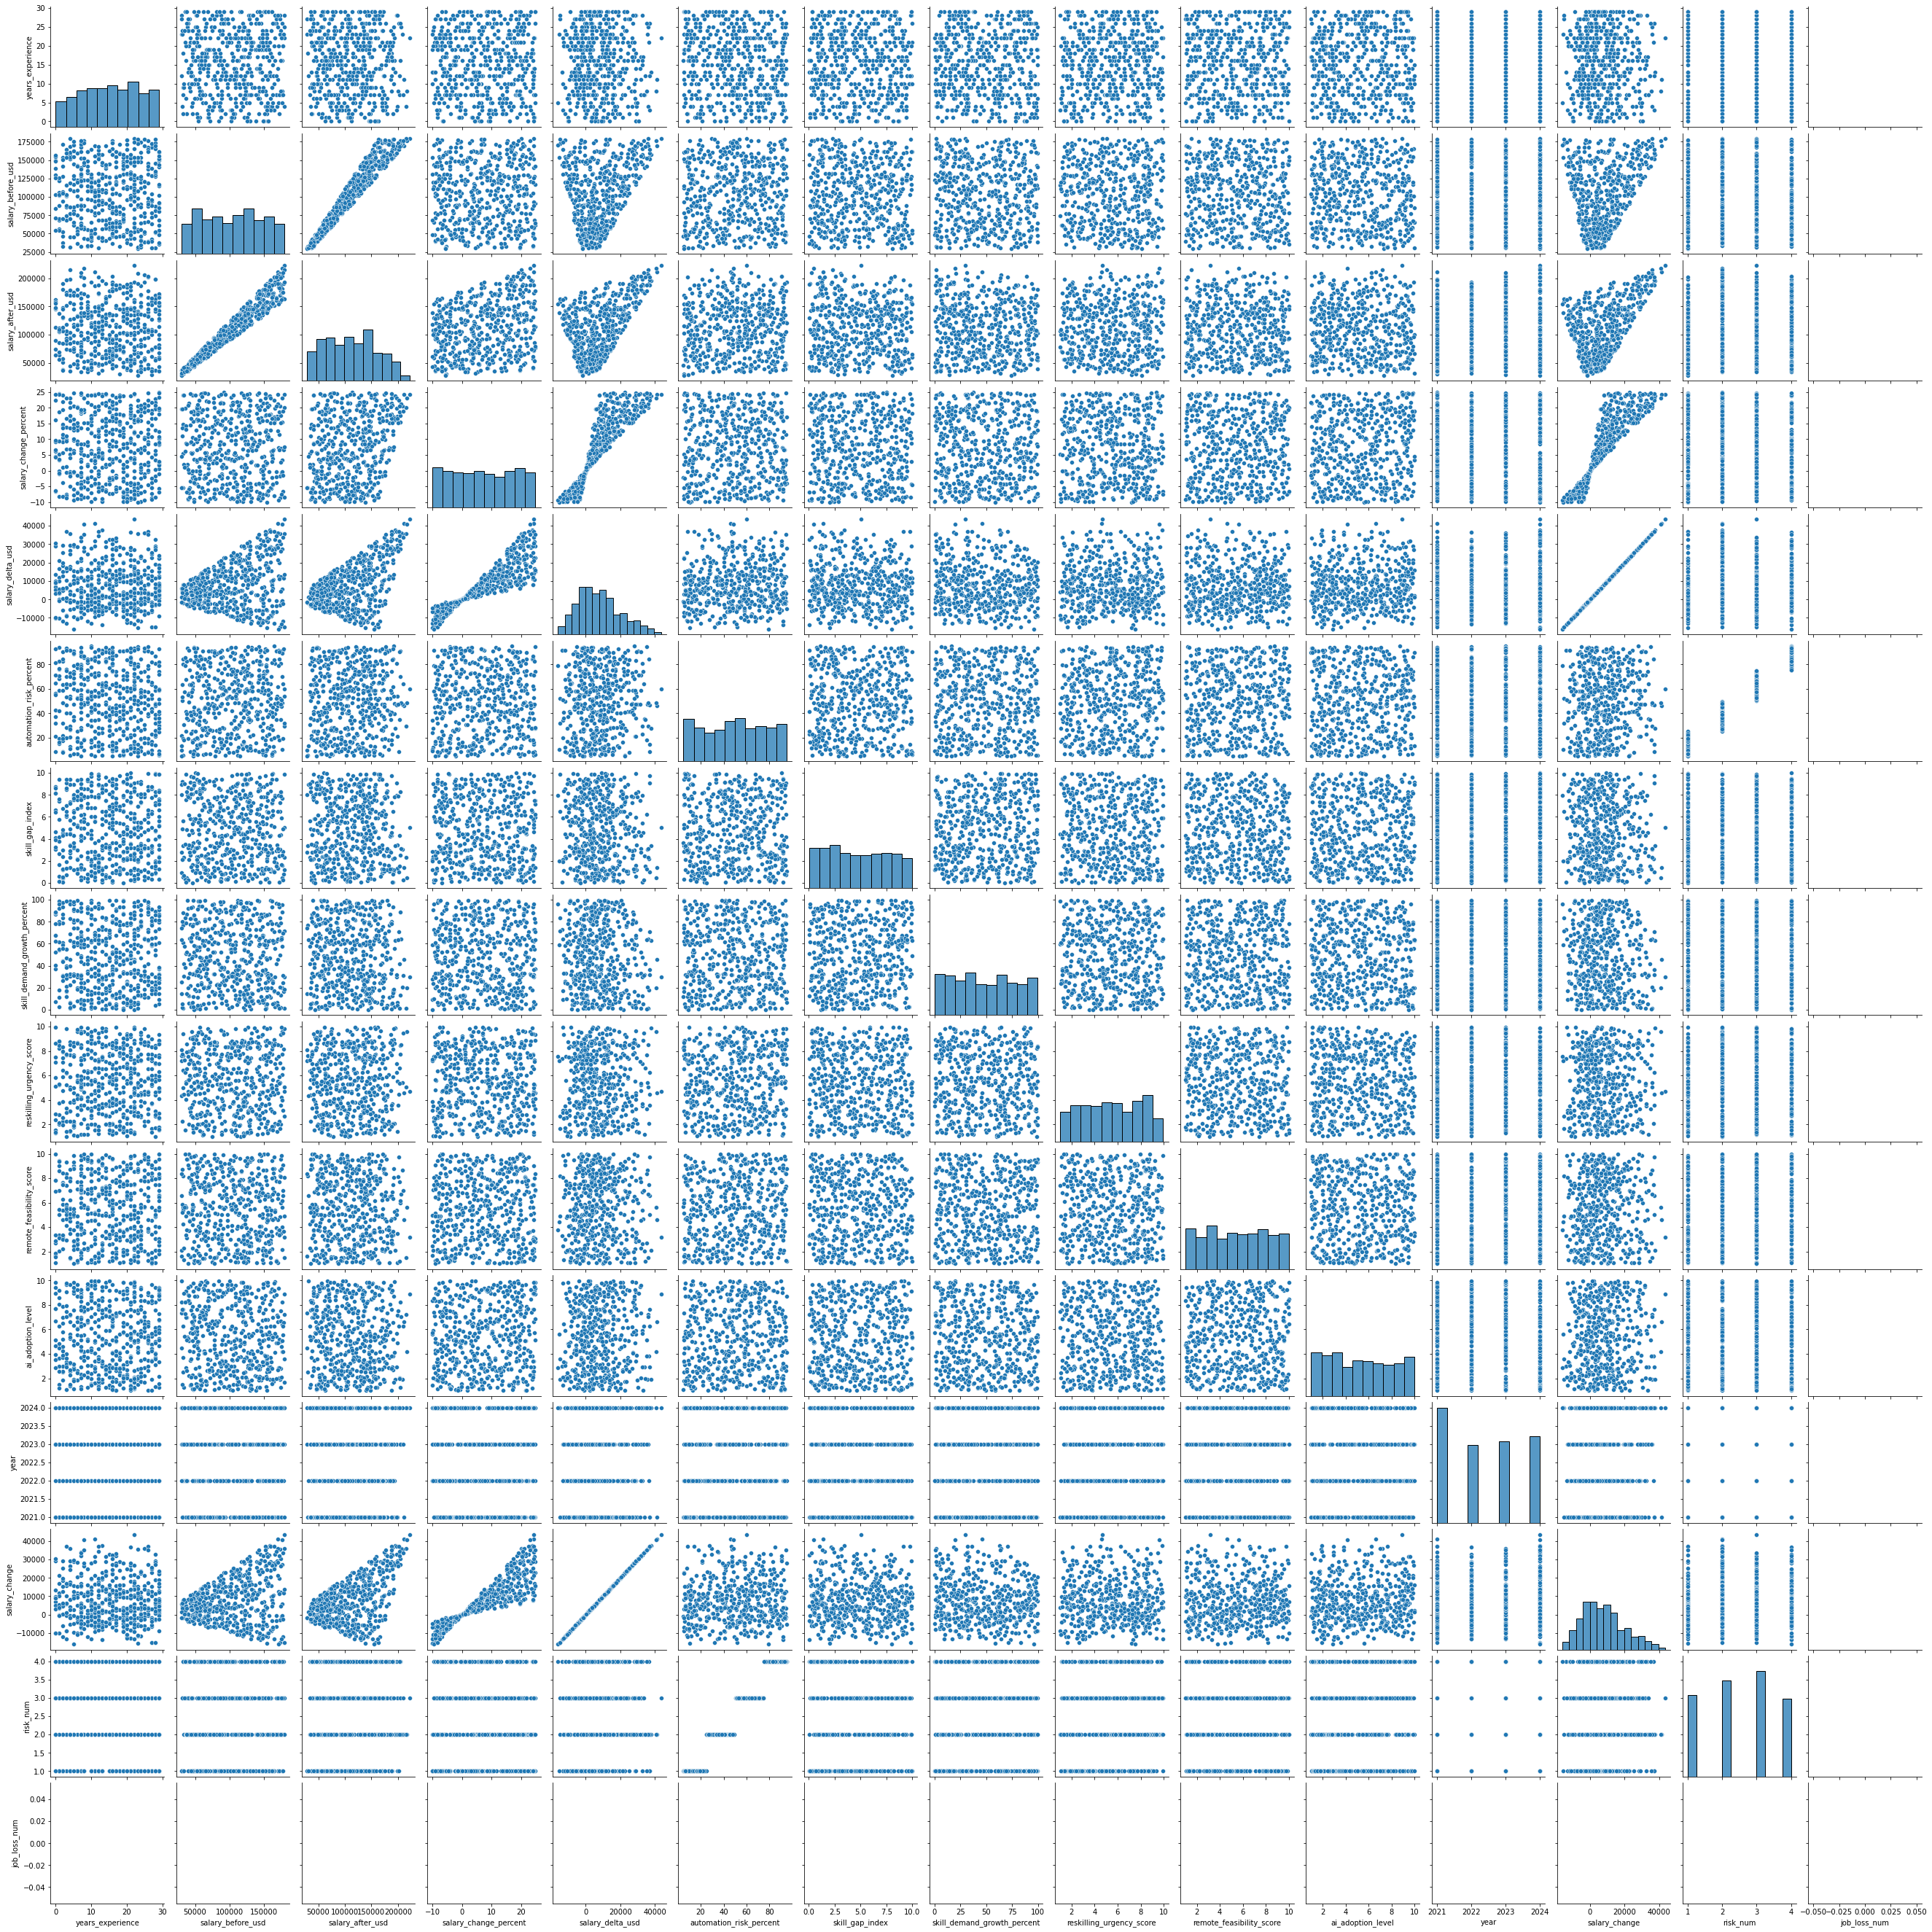

In [45]:
sns.pairplot(ai)

## Insights

- Strong positive relationships are visible between salary-related variables, especially salary before and after AI adoption.
- Automation risk variables show consistent linear relationships, validating the feature engineering process.
- Several workforce variables display weak or scattered relationships, suggesting AI-driven job disruption depends on multiple factors.
- Skill gap and reskilling urgency appear moderately related, indicating employees with larger skill deficiencies require faster intervention.
- Some outliers are visible, representing employees or roles with unusually high salary changes or automation exposure.
- The pairplot highlights that salary variables are more strongly correlated than workforce adaptation variables.


## Interpretation
- The pairplot shows that AI impacts salaries, automation risk, and workforce adaptability differently, highlighting the importance of reskilling and adaptability in an AI-driven job market.

# Project conclusion
- This analysis demonstrates that AI adoption significantly influences automation risk, job stability, salary trends, and workforce skill requirements. Employees in repetitive or operational roles face higher vulnerability, while adaptable and strategic roles remain more resilient. The findings highlight the growing importance of reskilling and continuous learning in maintaining employability within an AI-driven economy.